## Preparation

In [9]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

In [10]:
train_data = pd.read_csv("data/train.csv")
y_train = train_data[["PassengerId", "Survived"]]
X_test = pd.read_csv("data/test.csv")
y_test = pd.read_csv("data/gender_submission.csv")

## Analysis

In [11]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
# удаление всех категориальных фичей
cat_features = ["PassengerId", "Name", "Sex", "Ticket", "Cabin", "Embarked"]
train_data = train_data.drop(cat_features, axis=1)
train_data.head()

,Survived,Pclass,Age,SibSp,Parch,Fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


In [9]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
train_data.groupby("Survived").mean()

,Pclass,Age,SibSp,Parch,Fare
Survived,,,,,
0,2.531876,30.626179,0.553734,0.329690,22.117887
1,1.950292,28.343690,0.473684,0.464912,48.395408


In [17]:
train_data.groupby(train_data["Age"].isna()).mean()

,Survived,Pclass,Age,SibSp,Parch,Fare
Age,,,,,,
False,0.406162,2.236695,29.699118,0.512605,0.431373,34.694514
True,0.293785,2.598870,NaN,0.564972,0.180791,22.158567


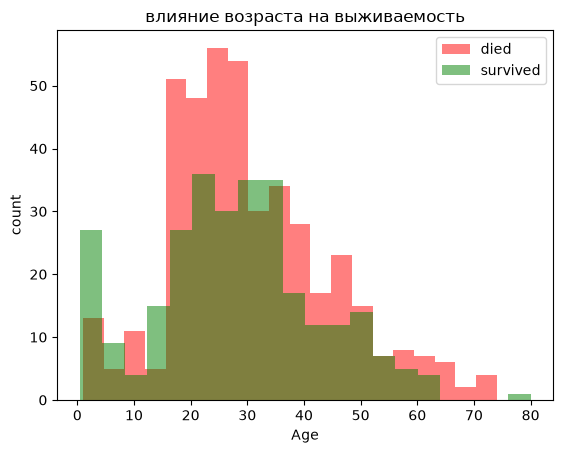

In [47]:
# график влияния возраста на выживаемость
plt.title("влияние возраста на выживаемость")

died = list(train_data[train_data["Survived"] == 0]["Age"].dropna())
survived = list(train_data[train_data["Survived"] == 1]["Age"].dropna())

plt.hist(died, color="red", alpha=0.5, label="died", bins=20) 
plt.hist(survived, color="green", alpha=0.5, label="survived", bins=20) 

plt.xlabel("Age")
plt.ylabel("count")  # сколько человек с таким возрастом выжило/погибло

plt.legend()
plt.show()

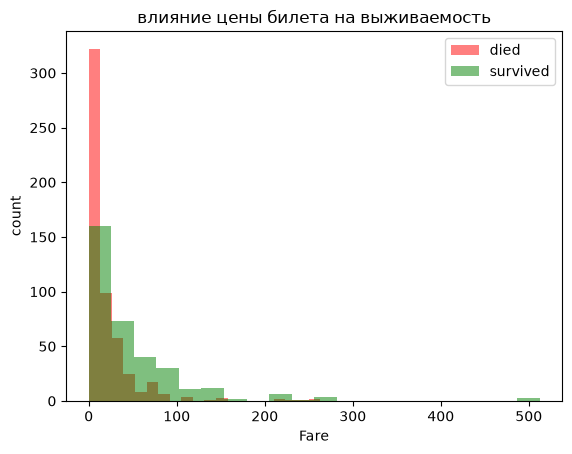

In [41]:
# график влияния цены билета на выживаемость
plt.title("влияние цены билета на выживаемость")

died = list(train_data[train_data["Survived"] == 0]["Fare"].dropna())
survived = list(train_data[train_data["Survived"] == 1]["Fare"].dropna())

plt.hist(died, color="red", alpha=0.5, label="died", bins=20) 
plt.hist(survived, color="green", alpha=0.5, label="survived", bins=20) 

plt.xlabel("Fare")
plt.ylabel("count")  # сколько человек с такой ценой билета выжило/погибло

plt.legend()
plt.show()

In [14]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64